In [161]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Hypotheses

**Null Hypothesis (H₀):** Blue Jays pitchers show no significant change in velocity, spin rate, or command (release point deviation) as pitch count increases within a game — i.e., game phase (Early / Mid / Late) has no effect on these mechanics.

**Alternative Hypothesis (H₁):** Blue Jays pitchers exhibit measurable fatigue as pitch count increases — specifically, velocity and/or spin rate decrease, and command worsens (greater release point deviation) in later game phases compared to earlier phases.

In [162]:

general_df = pd.read_csv('dataset_cleaned.csv')
general_df

,Unnamed: 0,game_year,game_date,player_name,pitcher,batter,balls,strikes,inning,inning_topbot,at_bat_number,pitch_number,events,pitch_type,pitch_name,release_speed,release_pos_x,release_pos_z,description,zone,des,game_type,stand,p_throws,home_team,away_team,type,hit_location,bb_type,pfx_x,pfx_z,plate_x,plate_z,on_3b,on_2b,on_1b,outs_when_up,hc_x,hc_y,fielder_2,vx0,vy0,vz0,ax,ay,az,sz_top,sz_bot,hit_distance_sc,launch_speed,launch_angle,effective_speed,release_spin_rate,release_extension,game_pk,fielder_2.3,fielder_3,fielder_4,fielder_5,fielder_6,fielder_7,fielder_8,fielder_9,release_pos_y,estimated_ba_using_speedangle,estimated_woba_using_speedangle,woba_value,woba_denom,babip_value,iso_value,launch_speed_angle,home_score,away_score,bat_score,fld_score,post_away_score,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length,cum_pitch_count,game_phase,score_diff
0,0,2025,2025-10-04,"Domínguez, Seranthony",622554,683011,0,0,7,Top,49,1,NaN,FF,4-Seam Fastball,96.5,-2.16,5.52,called_strike,6,Called Strike,D,R,R,TOR,NYY,S,NaN,NaN,-0.52,1.16,0.61,2.41,0.0,0.0,641857.0,1,NaN,NaN,672386,8.555977,-140.254297,-5.346834,-8.699338,30.955113,-15.876382,3.37,1.56,NaN,NaN,NaN,96.7,2258.0,6.4,813063,672386,665489,676391,680718,665926,623993,662139,664770,54.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1,1,2,1,2,1,2,Standard,Standard,217.0,0.000,-0.040,NaN,NaN,1,Late,-1
1,1,2025,2025-10-04,"Domínguez, Seranthony",622554,683011,0,1,7,Top,49,2,NaN,FF,4-Seam Fastball,96.6,-1.84,5.65,ball,12,Ball,D,R,R,TOR,NYY,B,NaN,NaN,-0.42,1.32,1.40,2.74,0.0,0.0,641857.0,1,NaN,NaN,672386,9.629481,-140.302211,-5.181498,-7.703501,31.135848,-13.759743,3.44,1.63,NaN,NaN,NaN,97.0,2294.0,6.6,813063,672386,665489,676391,680718,665926,623993,662139,664770,53.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1,1,2,1,2,1,2,Standard,Standard,208.0,0.000,0.019,NaN,NaN,2,Late,-1
2,2,2025,2025-10-04,"Domínguez, Seranthony",622554,683011,1,1,7,Top,49,3,NaN,ST,Sweeper,85.8,-1.92,5.65,ball,11,Ball,D,R,R,TOR,NYY,B,NaN,NaN,0.54,0.73,-0.11,4.14,0.0,0.0,641857.0,1,NaN,NaN,672386,3.191911,-124.907331,1.213145,5.019442,25.884644,-24.984622,3.41,1.58,NaN,NaN,NaN,85.9,2482.0,6.4,813063,672386,665489,676391,680718,665926,623993,662139,664770,54.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1,1,2,1,2,1,2,Standard,Standard,93.0,0.000,0.063,NaN,NaN,3,Late,-1
3,3,2025,2025-10-04,"Domínguez, Seranthony",622554,683011,2,1,7,Top,49,4,NaN,FF,4-Seam Fastball,96.9,-2.10,5.55,swinging_strike,4,Swinging Strike,D,R,R,TOR,NYY,S,NaN,NaN,-0.52,1.16,-0.41,2.52,0.0,0.0,676609.0,1,NaN,NaN,672386,5.717609,-140.880859,-5.171986,-8.195574,33.160330,-15.811606,3.41,1.61,NaN,NaN,NaN,96.9,2249.0,6.4,813063,672386,665489,676391,680718,665926,623993,662139,664770,54.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1,1,2,1,2,1,2,Standard,Standard,209.0,0.000,-0.075,69.1,5.9,4,Late,-1
4,4,2025,2025-10-04,"Domínguez, Seranthony",622554,683011,2,2,7,Top,49,5,strikeout,FF,4-Seam Fastball,97.7,-1.83,5.57,called_strike,9,Anthony Volpe called out on strikes.,D,R,R,TOR,NYY,S,2.0,NaN,-0.61,1.26,0.70,2.00,0.0,0.0,676609.0,1,NaN,NaN,672386,8.294276,-141.946342,-7.052648,-10.192045,32.355239,-13.699090,3.45,1.61,NaN,NaN,NaN,98.2,2354.0,6.6,813063,672386,665489,676391,680718,665926,623993,662139,664770,53.86,NaN,0.000,0.0,1.0,0.0,0.0,NaN,2,1,1,2,1,2,1,2,Standard,Standard,217.0,0.055,-0.221,NaN,NaN,5,Late,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2617,2617,2025,2025-11-01,"Yesavage, Trey",702056,571970,0,0,8,Top,66,1,NaN,FS,Split-Finger,82.4,-0.40,7.29,called_strike,12,Called Strike,W,L,R,TOR,LAD,S,NaN,NaN,-1.04,0.56,0.23,3.47,0.0,0.0,0.0,1,NaN,NaN,672386,3.439316,-120.0162

In [163]:
print(general_df.shape)
general_df['cum_pitch_count'].describe()

(2622, 89)


count    2622.000000
mean       26.181541
std        24.228103
min         1.000000
25%         7.000000
50%        16.000000
75%        43.000000
max       104.000000
Name: cum_pitch_count, dtype: float64

In [164]:
print('Number of games: ', general_df['game_pk'].nunique())
print('Number of pitchers: ', general_df['pitcher'].nunique())

Number of games:  18
Number of pitchers:  15


In [165]:
my_vars = ['release_speed', 'release_spin_rate', 'delta_run_exp', 'pitch_name', 'cum_pitch_count']
general_df[my_vars].isnull().sum()

release_speed        0
release_spin_rate    0
delta_run_exp        0
pitch_name           0
cum_pitch_count      0
dtype: int64

pitch_name
4-Seam Fastball    921
Slider             511
Split-Finger       338
Cutter             195
Knuckle Curve      143
Sinker             141
Curveball          132
Changeup           123
Sweeper            118
Name: count, dtype: int64


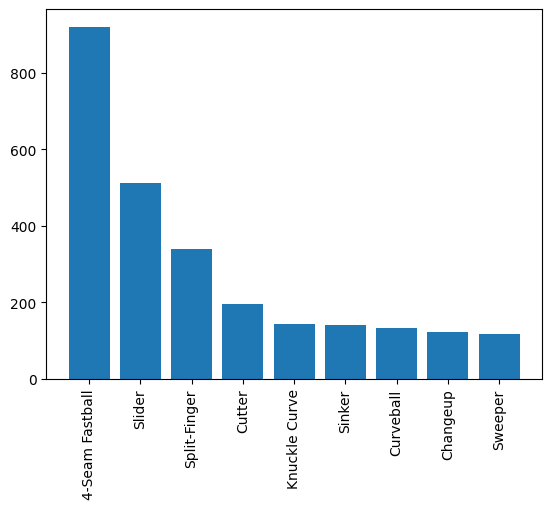

In [166]:
plt.bar(general_df['pitch_name'].value_counts().index, general_df['pitch_name'].value_counts().values)
plt.xticks(rotation=90)
print(general_df['pitch_name'].value_counts())

In [167]:
general_df['inning'].value_counts().sort_index()

inning
1     296
2     278
3     301
4     256
5     244
6     279
7     299
8     265
9     249
10     39
11     27
12     12
13      8
14     26
15     14
16     11
17     13
18      5
Name: count, dtype: int64

In [172]:
substitute = (general_df[general_df['inning'] >= 10].groupby('player_name').agg(
    min_inning=('inning', 'min'),
    max_inning=('inning', 'max'), 
    min_cum=('cum_pitch_count', 'min'), 
    max_cum=('cum_pitch_count', 'max'), 
    total_pitches=('cum_pitch_count', 'count')).sort_values('min_inning'))

substitute

,min_inning,max_inning,min_cum,max_cum,total_pitches
player_name,,,,,
"Domínguez, Seranthony",10,10,1,24,24
"Hoffman, Jeff",10,10,14,28,15
"Bieber, Shane",11,11,1,12,12
"Fisher, Braydon",11,12,1,19,19
"Lauer, Eric",12,16,1,67,67
"Little, Brendon",17,18,1,18,18


In [169]:
general_df.groupby('pitch_name')['release_speed'].mean().sort_values(ascending=False)

pitch_name
4-Seam Fastball    94.990662
Sinker             94.377305
Cutter             90.247179
Changeup           89.638211
Slider             87.239139
Knuckle Curve      86.526573
Split-Finger       84.606213
Sweeper            83.494915
Curveball          79.026515
Name: release_speed, dtype: float64

In [170]:
general_df[general_df['inning'] > 7].head()  

,Unnamed: 0,game_year,game_date,player_name,pitcher,batter,balls,strikes,inning,inning_topbot,at_bat_number,pitch_number,events,pitch_type,pitch_name,release_speed,release_pos_x,release_pos_z,description,zone,des,game_type,stand,p_throws,home_team,away_team,type,hit_location,bb_type,pfx_x,pfx_z,plate_x,plate_z,on_3b,on_2b,on_1b,outs_when_up,hc_x,hc_y,fielder_2,vx0,vy0,vz0,ax,ay,az,sz_top,sz_bot,hit_distance_sc,launch_speed,launch_angle,effective_speed,release_spin_rate,release_extension,game_pk,fielder_2.3,fielder_3,fielder_4,fielder_5,fielder_6,fielder_7,fielder_8,fielder_9,release_pos_y,estimated_ba_using_speedangle,estimated_woba_using_speedangle,woba_value,woba_denom,babip_value,iso_value,launch_speed_angle,home_score,away_score,bat_score,fld_score,post_away_score,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length,cum_pitch_count,game_phase,score_diff
80,80,2025,2025-10-04,"Hoffman, Jeff",656546,519317,0,0,9,Top,72,1,NaN,FF,4-Seam Fastball,96.8,-2.60,5.68,called_strike,6,Called Strike,D,R,R,TOR,NYY,S,NaN,NaN,-1.18,1.43,0.54,2.48,0.0,0.0,0.0,0,NaN,NaN,672386,11.114566,-140.281283,-6.179732,-18.246111,35.369314,-12.087181,3.75,1.84,NaN,NaN,NaN,96.7,2570.0,6.7,813063,672386,665489,643396,676391,665926,664702,662139,664770,53.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,1,1,10,1,10,1,10,Standard,Standard,220.0,0.0,-0.039,NaN,NaN,1,Late,-9
81,81,2025,2025-10-04,"Hoffman, Jeff",656546,519317,0,1,9,Top,72,2,field_out,FF,4-Seam Fastball,96.5,-2.64,5.63,hit_into_play,2,Giancarlo Stanton pops out to third baseman Er...,D,R,R,TOR,NYY,X,5.0,popup,-1.18,1.37,-0.17,3.83,0.0,0.0,0.0,0,89.66,177.94,672386,9.314686,-140.151855,-2.280976,-17.742332,35.759151,-13.891543,3.80,1.84,146.0,90.2,67.0,96.6,2637.0,6.8,813063,672386,665489,643396,676391,665926,664702,662139,664770,53.74,0.009,0.011,0.0,1.0,0.0,0.0,3.0,10,1,1,10,1,10,1,10,Standard,Standard,224.0,0.0,-0.220,74.1,8.5,2,Late,-9
82,82,2025,2025-10-04,"Hoffman, Jeff",656546,665862,0,0,9,Top,73,1,NaN,FF,4-Seam Fastball,96.8,-2.57,5.65,foul,7,Foul,D,L,R,TOR,NYY,S,NaN,NaN,-1.03,1.39,-0.34,2.14,0.0,0.0,0.0,1,NaN,NaN,672386,8.346314,-140.589423,-7.038383,-15.466544,30.133499,-12.317952,3.68,1.72,171.0,83.2,14.0,97.5,2631.0,6.7,813063,672386,665489,643396,676391,665926,664702,662139,664770,53.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,1,1,10,1,10,1,10,Infield shade,Standard,224.0,0.0,-0.039,72.9,7.8,3,Late,-9
83,83,2025,2025-10-04,"Hoffman, Jeff",656546,665862,0,1,9,Top,73,2,NaN,FF,4-Seam Fastball,95.6,-2.52,5.57,ball,12,Ball,D,L,R,TOR,NYY,B,NaN,NaN,-1.18,1.25,0.90,2.98,0.0,0.0,0.0,1,NaN,NaN,672386,11.735438,-138.723464,-4.054184,-17.756225,29.837355,-15.198703,3.74,1.78,NaN,NaN,NaN,96.4,2570.0,6.8,813063,672386,665489,643396,676391,665926,664702,662139,664770,53.68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,1,1,10,1,10,1,10,Infield shade,Standard,223.0,0.0,0.028,NaN,NaN,4,Late,-9
84,84,2025,2025-10-04,"Hoffman, Jeff",656546,665862,2,1,9,Top,73,4,NaN,SL,Slider,87.3,-2.44,5.65,swinging_strike,6,Swinging Strike,D,L,R,TOR,NYY,S,NaN,NaN,0.29,0.14,0.48,2.80,0.0,0.0,0.0,1,NaN,NaN,672386,6.456413,-127.212530,-1.136933,2.195754,20.699298,-30.644053,3.68,1.72,NaN,NaN,NaN,88.6,2674.0,6.6,813063,672386,665489,643396,676391,665926,664702,662139,664770,53.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,1,1,10,1,10,1,10,Infield shade,Standard,96.0,0.0,-0.070,76.5,8.9,5,Late,-9


Takeaway:
- Blue Jays may have a lot of relievers
- cum_pitch_count --> Right skewed distribution 
- 4 Seam Fastball thrown most. Curveball thrown least

- Extra innings (inning 10+) will be dropped for Q1 analysis. 
  cum_pitch_count resets for each new pitcher, meaning a reliever 
  entering in inning 14 at pitch count 1 is indistinguishable from 
  a starter's pitch 1 in inning 1. Including extra innings would 
  confound the fatigue signal.

- All 9 pitch types pass the 90-observation threshold overall, but 
  sample sizes may become thin when split by individual pitcher. 
  Analysis will be done at the aggregate level first.

- The right-skewed cum_pitch_count distribution (mean=26, median=16, 
  max=104) suggests most pitchers are relievers throwing fewer than 
  43 pitches. The fatigue signal, if it exists, will be driven 
  primarily by the small number of starters reaching high pitch counts.